# **Executive Summary**

## Project Overview

This project analyzes IT asset data from multiple sources to identify data quality issues and assess their relationship with device risk.

The analysis combines exploratory data analysis, data quality assessment, statistical testing, and risk classification with statistical validation

## Key Findings

The dataset contains 141 computers. The overall risk distribution is:

- **41 Low Risk computers (29.1%)**
- **60 Medium Risk computers (42.6%)**
- **40 High Risk computers (28.4%)**

The most widespread data quality issue is **location mismatch**, affecting 108 computers (76.6%). However, its statistical association with high risk is relatively weak, with an odds ratio of 1.15.

In contrast, **missing from Primend** affects 36 computers (25.5%) but has the strongest association with High Risk, with an odds ratio of 27.24.

Other important risk indicators include:

- **Missing login data** — 53 computers (37.6%), odds ratio 6.81
- **Inactive device** — 7 computers (5.0%), odds ratio 2.02
- **Missing from SharePoint** — 44 computers (31.2%), odds ratio 1.34

Statistical analysis also identified a strong relationship between asset status and risk level (Chi-square = 221.89, p < 0.001, Cramér's V = 0.887).

## Predictive Model

A Logistic Regression model was developed to classify computers as High Risk or Not High Risk.

The model achieved:

- **Accuracy: 94.4%**
- **Precision: 100.0%**
- **Recall: 80.0%**
- **F1-score: 88.9%**
- **ROC-AUC: 98.1%**

A classification threshold of **0.30** was selected to balance precision and recall.

The model correctly identified 8 of 10 High Risk computers in the test set, while producing no false positives at the selected threshold.

### Methodological Limitation

The High Risk label is constructed from the same data quality indicators used as model features. Therefore, the Logistic Regression model should be interpreted as a statistical validation of the relationship between risk indicators and the constructed High Risk classification, rather than as an independent predictive model of future operational risk.

An independently observed outcome variable would be required to evaluate true future-risk prediction.

## Main Insight

The analysis demonstrates that the most common data quality issue is not necessarily the most important predictor of operational risk.

Therefore, data quality improvements should be prioritized using both:

1. **Prevalence of the problem**
2. **Relationship between the problem and device risk**

This approach allows IT teams to focus remediation efforts on issues that are most likely to have an impact on device risk.

# **IT Asset Data Quality & Reconciliation**

In [154]:
import pandas as pd

df = pd.read_excel("/IT_Asset_Analytics_an.xlsx", sheet_name="Arvutid")

df.head()
df.shape
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 141 entries, 0 to 140
Data columns (total 23 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Computer Name(Sharepoint)    85 non-null     object 
 1   Computer user (Sharepoint)   122 non-null    object 
 2   Computer Name (Ülevaade)     104 non-null    object 
 3   Computer Name(All)           140 non-null    object 
 4   Primend kasutaja (kontroll)  42 non-null     object 
 5   Asukoht Sharepointis         139 non-null    object 
 6   Kas on Sharepointis?         139 non-null    object 
 7   Asukoht Primendis            139 non-null    object 
 8   Kas on Primendis?            139 non-null    object 
 9   Viimane login                139 non-null    object 
 10  Viimane boot                 139 non-null    object 
 11  Asukoht mapping              139 non-null    object 
 12  Lõpp asukoht                 139 non-null    object 
 13  Unnamed: 13         

In [155]:
# Anonymize sensitive raw columns while preserving their meaning

# SharePoint / Primend presence
df["Kas on Sharepointis?"] = df["Kas on Sharepointis?"].notna()
df["Kas on Primendis?"] = df["Kas on Primendis?"].notna()

# Login / boot information
df["Viimane login"] = df["Viimane login"].apply(
    lambda x: "Login data available" if pd.notna(x) and x != "Puudub" else "Puudub"
)

df["Viimane boot"] = df["Viimane boot"].apply(
    lambda x: "Boot data available" if pd.notna(x) and x != "Puudub" else "Puudub"
)

In [156]:
df["Kas on Sharepointis?"].value_counts(dropna=False) #Dropna reflects to still count NaN values
df["Kas on Sharepointis?"].unique()

array([ True, False])

In [157]:
df["sharepoint_exists"] = df["Computer Name(Sharepoint)"].notna()  #Notna checks for value

df[["Computer Name(All)", "Computer Name(Sharepoint)", "sharepoint_exists"]].head(10)

,Computer Name(All),Computer Name(Sharepoint),sharepoint_exists
0,PC_564,PC_564,True
1,PC_565,PC_565,True
2,PC_086,PC_086,True
3,PC_044,PC_044,True
4,PC_076,PC_076,True
5,PC_001,PC_001,True
6,PC_061,PC_061,True
7,PC_566,PC_566,True
8,PC_567,PC_567,True
9,PC_568,PC_568,True


In [158]:
df["primend_exists"] = df["Kas on Primendis?"] != "Puudub"
df[["Computer Name (Ülevaade)", "Kas on Primendis?", "primend_exists"]].head(10)

,Computer Name (Ülevaade),Kas on Primendis?,primend_exists
0,PC_001,True,True
1,PC_002,True,True
2,PC_003,True,True
3,PC_004,True,True
4,PC_005,True,True
5,PC_006,True,True
6,PC_007,True,True
7,PC_008,True,True
8,PC_009,True,True
9,PC_010,True,True


In [159]:
df["Kas on Primendis?"].value_counts(dropna=False)

,count
Kas on Primendis?,
True,139
False,2


##  Question 1: Which devices we have in Sharepoint and Primend only, and which ones are findable in both?

In [160]:
asset_status = []

for row in df.itertuples():

    if row.sharepoint_exists and row.primend_exists:
        asset_status.append("Both")

    elif row.sharepoint_exists and not row.primend_exists:
        asset_status.append("SharePoint only")

    elif not row.sharepoint_exists and row.primend_exists:
        asset_status.append("Primend only")

    else:
        asset_status.append("Neither")

df["asset_status"] = asset_status

df[[
    "Computer Name(All)",
    "sharepoint_exists",
    "primend_exists",
    "asset_status"
]].head(20)

,Computer Name(All),sharepoint_exists,primend_exists,asset_status
0,PC_564,True,True,Both
1,PC_565,True,True,Both
2,PC_086,True,True,Both
3,PC_044,True,True,Both
4,PC_076,True,True,Both
5,PC_001,True,True,Both
6,PC_061,True,True,Both
7,PC_566,True,True,Both
8,PC_567,True,True,Both
9,PC_568,True,True,Both


Analyzed IT asset records across two inventory sources and identified inconsistencies in device presence:

In [161]:
df["asset_status"].value_counts()

,count
asset_status,
Both,85
Primend only,56


Insight:
Only 49 out of 141 records match between the two sources based on our current logic.
Meanwhile, 92 records fall into the "Primend only," "SharePoint only," or "Neither" categories.

## Question 2 : But why are they different?

It is possible that:

* the computer is actually missing from Primend;
*  its name is recorded differently in Primend;
* the user exists, but the computer name is different;
* the record is outdated;
* it is a special type of device altogether.




In [162]:
df["asset_status"].value_counts(normalize=True) * 100
#Instead of the count, give me the share of the total records. And multiplying by 100 converts it into a percentage

,proportion
asset_status,
Both,60.283688
Primend only,39.716312


Insight: 34.75% are present in both systems, while 65.25% do not show a complete match between them.

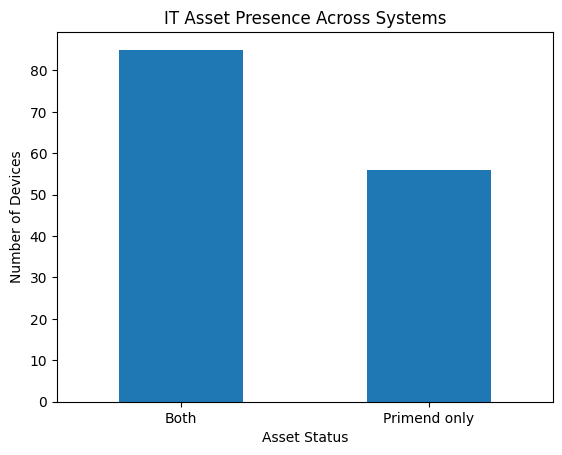

In [163]:
import matplotlib.pyplot as plt

df["asset_status"].value_counts().plot(kind="bar")

plt.title("IT Asset Presence Across Systems")
plt.xlabel("Asset Status")
plt.ylabel("Number of Devices")
plt.xticks(rotation=0)
plt.show()

## Question 3: Is there a connection between the presence of a computer in the systems and its actual activity?

In [164]:
df_logs = pd.read_excel(
    "/IT_Asset_Analytics_an.xlsx",
    sheet_name="Tabel kokku"
)
# Remove columns containing raw / sensitive identifiers
df_logs = df_logs.drop(
    columns=[
        "Unnamed: 10",
        "Unnamed: 11",
        "Unnamed: 12",
        "Unnamed: 13"
    ],
    errors="ignore"
)

df_logs.head(10)
df_logs.head(10)

,Arvuti nimi (kõik),Kasutaja (kõik),Arvuti nimi (logs),Kasutaja (logs),arvuti (logs) referred to C,Kui kaua tagasi oli log tehtud:,arvuti 2 logs date formatted,2026-07-20 00:00:00,"Arvutid, kus log tehtud üle 200 päeva tagasi",Unnamed: 9
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,PC_001,User_001,PC_001,User_093,PC_110,162,PC_206,NaN,PC_296,NaN
2,PC_002,User_002,PC_002,User_094,PC_111,164,PC_207,NaN,PC_296,NaN
3,PC_003,User_003,PC_003,User_095,PC_112,182,PC_208,NaN,PC_296,NaN
4,PC_004,User_004,PC_004,User_096,PC_113,237,PC_209,NaN,PC_296,NaN
5,PC_005,User_005,PC_005,User_097,PC_114,187,PC_210,NaN,PC_296,NaN
6,PC_006,User_006,PC_006,User_098,PC_115,172,PC_211,NaN,PC_296,NaN
7,PC_007,User_007,PC_094,User_099,PC_116,290,PC_212,NaN,PC_296,NaN
8,PC_008,User_008,PC_007,User_100,PC_117,162,PC_206,NaN,PC_296,NaN
9,PC_009,User_009,PC_008,User_101,PC_118,167,PC_213,NaN,PC_296,NaN


In [165]:
df_logs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 202 entries, 0 to 201
Data columns (total 10 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Arvuti nimi  (kõik)                           109 non-null    object 
 1   Kasutaja (kõik)                               108 non-null    object 
 2   Arvuti nimi  (logs)                           115 non-null    object 
 3   Kasutaja (logs)                               112 non-null    object 
 4   arvuti  (logs) referred to C                  96 non-null     object 
 5   Kui kaua tagasi oli log tehtud:               188 non-null    object 
 6   arvuti 2 logs date formatted                  175 non-null    object 
 7   2026-07-20 00:00:00                           93 non-null     object 
 8   Arvutid, kus log tehtud üle 200 päeva tagasi  187 non-null    object 
 9   Unnamed: 9                                    0 non-null      flo

In [166]:
df_logs["days_since_login"] = pd.to_numeric(
    df_logs["Kui kaua tagasi oli log tehtud:"],  #How long ago log was made
    errors="coerce"
)

df_logs[[
    "Arvuti nimi  (kõik)",
    "Kui kaua tagasi oli log tehtud:",
    "days_since_login"
]].head(10)

,Arvuti nimi (kõik),Kui kaua tagasi oli log tehtud:,days_since_login
0,NaN,NaN,NaN
1,PC_001,162,162.0
2,PC_002,164,164.0
3,PC_003,182,182.0
4,PC_004,237,237.0
5,PC_005,187,187.0
6,PC_006,172,172.0
7,PC_007,290,290.0
8,PC_008,162,162.0
9,PC_009,167,167.0


Is the device status (Both, Primend only, SharePoint only, Neither) related to how long ago it was used?

In [167]:
df[["Computer Name(All)", "asset_status"]].head()

,Computer Name(All),asset_status
0,PC_564,Both
1,PC_565,Both
2,PC_086,Both
3,PC_044,Both
4,PC_076,Both


In [168]:
df_logs[["Arvuti nimi  (kõik)", "days_since_login"]].head()

,Arvuti nimi (kõik),days_since_login
0,NaN,NaN
1,PC_001,162.0
2,PC_002,164.0
3,PC_003,182.0
4,PC_004,237.0


In [169]:
df["Computer Name(All)"] = df["Computer Name(All)"].astype(str).str.strip() #Take the computer names and remove any accidental leading or trailing spaces.

df_logs["Arvuti nimi  (kõik)"] = df_logs["Arvuti nimi  (kõik)"].astype(str).str.strip()

In [170]:
df_master = df.merge(
    df_logs[["Arvuti nimi  (kõik)", "days_since_login"]],
    left_on="Computer Name(All)",
    right_on="Arvuti nimi  (kõik)",
    how="left"
)
#Take our main table "df" and add "days_since_login" from "df_logs" to it, matching computers by their names.
#how="left" means: keep all 141 computers from our main table, even if no log is found for a particular computer.

In [171]:
# ==============================
# Data cleaning / derived fields
# ==============================

import numpy as np

# Clean computer name
df_master["Computer Name(All) clean"] = (
    df_master["Computer Name(All)"]
    .replace("nan", pd.NA)
)

# Clean SharePoint user
df_master["Computer user (Sharepoint) clean"] = (
    df_master["Computer user (Sharepoint)"]
)

df_master.loc[
    df_master["Computer Name(Sharepoint)"].isna(),
    "Computer user (Sharepoint) clean"
] = pd.NA

print("Clean columns created successfully.")

print(
    "Missing computer names:",
    df_master["Computer Name(All) clean"].isna().sum()
)

print(
    "Missing SharePoint users:",
    df_master["Computer user (Sharepoint) clean"].isna().sum()
)

Clean columns created successfully.
Missing computer names: 93
Missing SharePoint users: 156


In [172]:
df_master[[
    "Computer Name(All)",
    "asset_status",
    "days_since_login"
]].head(20)

,Computer Name(All),asset_status,days_since_login
0,PC_564,Both,NaN
1,PC_565,Both,NaN
2,PC_086,Both,180.0
3,PC_044,Both,171.0
4,PC_044,Both,NaN
5,PC_076,Both,287.0
6,PC_001,Both,162.0
7,PC_061,Both,166.0
8,PC_566,Both,NaN
9,PC_567,Both,NaN


Found, that some devices has several log cases - now I have to decide what should I do with them. I think that I will leave only the latest log.

In [173]:
df_logs[
    "Arvuti nimi  (kõik)"
].value_counts().head(20)

,count
Arvuti nimi (kõik),
nan,93
PC_093,7
PC_022,2
PC_024,2
PC_018,2
PC_015,2
PC_044,2
PC_049,2
PC_078,2


In [174]:
df_logs["Arvuti nimi  (kõik)"].duplicated().sum()

np.int64(108)

In [175]:
df_logs_clean = (
    df_logs
    .dropna(subset=["Arvuti nimi  (kõik)"])
    .groupby("Arvuti nimi  (kõik)", as_index=False)["days_since_login"]
    .min()
)

In [176]:
df_logs_clean.head(20)

,Arvuti nimi (kõik),days_since_login
0,PC_001,162.0
1,PC_002,164.0
2,PC_003,182.0
3,PC_004,237.0
4,PC_005,187.0
5,PC_006,172.0
6,PC_007,290.0
7,PC_008,162.0
8,PC_009,167.0
9,PC_010,194.0


In [177]:
df_logs_clean.shape

(94, 2)

Create a new master


In [178]:
df_master = df.merge(
    df_logs_clean,
    left_on="Computer Name(All)",
    right_on="Arvuti nimi  (kõik)",
    how="left"
)
df_master[[
    "Computer Name(All)",
    "asset_status",
    "days_since_login"
]].head(20)

,Computer Name(All),asset_status,days_since_login
0,PC_564,Both,NaN
1,PC_565,Both,NaN
2,PC_086,Both,180.0
3,PC_044,Both,171.0
4,PC_076,Both,287.0
5,PC_001,Both,162.0
6,PC_061,Both,166.0
7,PC_566,Both,NaN
8,PC_567,Both,NaN
9,PC_568,Both,NaN


In [179]:
print("Rows in master:", len(df_master))
print("Unique computers:", df_master["Computer Name(All)"].nunique())
print("Computers with login data:", df_master["days_since_login"].notna().sum())
print("Computers without login data:", df_master["days_since_login"].isna().sum())

Rows in master: 141
Unique computers: 141
Computers with login data: 89
Computers without login data: 52


## Question 4: For how long, on average, were computers used in each category?

In [180]:
df_master.groupby("asset_status")["days_since_login"].agg(
    ["count", "mean", "median", "min", "max"]
).round(1)

,count,mean,median,min,max
asset_status,,,,,
Both,46,191.2,167.5,162.0,304.0
Primend only,43,188.4,172.0,162.0,346.0


As long as currently "Neither" and "Sharepoint only" category has only NaN results, we have to do a double check.

In [181]:
pd.crosstab(
    df_master["asset_status"],
    df_master["days_since_login"].notna()
)

days_since_login,False,True
asset_status,,
Both,39,46
Primend only,13,43


In [182]:
df_master["has_login_data"] = df_master["days_since_login"].notna()

In [183]:
df_master["has_login_data"].value_counts()

,count
has_login_data,
True,89
False,52


Insight: Lack of login data strongly coincides with specific asset reconciliation statuses.

In [184]:
df_master[
    df_master["has_login_data"] == False
][[
    "Computer Name(All)",
    "asset_status",
    "days_since_login"
]]

,Computer Name(All),asset_status,days_since_login
0,PC_564,Both,NaN
1,PC_565,Both,NaN
7,PC_566,Both,NaN
8,PC_567,Both,NaN
9,PC_568,Both,NaN
10,PC_569,Both,NaN
11,PC_097,Both,NaN
14,PC_570,Both,NaN
17,PC_571,Both,NaN
23,PC_572,Both,NaN


Determine which category most frequently has missing login data, in percentage terms.

In [185]:
pd.crosstab(
    df_master["asset_status"],
    df_master["has_login_data"],
    normalize="index"
).round(3) * 100

has_login_data,False,True
asset_status,,
Both,45.9,54.1
Primend only,23.2,76.8


Insight: All 48 computers in the "SharePoint only" and "Neither" categories have no login data.

## Hypothesis: It is possible that these computers do not simply "lack a login," but are actually a special type of device, old records, or computers with a different naming scheme.

## Question 5: Why does SharePoint Online not have any login data at all?

* these devices are indeed old/inactive;
* they exist in SharePoint but are missing from the log source;
* their names do not match the names in the logs;
* they are special devices that are not logged in the standard way;
* the data in Tabel kokku is incomplete.

In [186]:
df_master[
    df_master["asset_status"] == "SharePoint only"
][[
    "Computer Name(All)",
    "Computer Name(Sharepoint)",
    "Computer user (Sharepoint)",
    "Asukoht Sharepointis",
    "Asukoht Primendis",
    "Lõpp asukoht"
]].head(20)

,Computer Name(All),Computer Name(Sharepoint),Computer user (Sharepoint),Asukoht Sharepointis,Asukoht Primendis,Lõpp asukoht


Neither category check


In [187]:
df_master[
    df_master["asset_status"] == "Neither"
][[
    "Computer Name(All)",
    "Computer Name(Sharepoint)",
    "Computer user (Sharepoint)",
    "Asukoht Sharepointis",
    "Asukoht Primendis",
    "Lõpp asukoht",
    "days_since_login"
]]

,Computer Name(All),Computer Name(Sharepoint),Computer user (Sharepoint),Asukoht Sharepointis,Asukoht Primendis,Lõpp asukoht,days_since_login


In [188]:
df_master[
    df_master["asset_status"] == "Neither"
]["Computer user (Sharepoint)"].value_counts()

,count
Computer user (Sharepoint),


In [189]:
df_master[
    df_master["asset_status"] == "Neither"
]["Lõpp asukoht"].value_counts()

,count
Lõpp asukoht,


Insight: The Neither category contains a highly concentrated group of 12 devices associated with the same user and location, with no corresponding SharePoint, Primend, or login records.

In [190]:
# Create cleaned computer name
df_master["Computer Name(All) clean"] = (
    df_master["Computer Name(All)"]
    .astype(str)
    .str.strip()
    .str.upper()
)

print("Clean computer name column created")

Clean computer name column created


In [191]:
sharepoint_only = df_master[
    df_master["asset_status"] == "SharePoint only"
]

sharepoint_only[
    [
        "Computer Name(All) clean",
        "Computer user (Sharepoint)",
        "days_since_login"
    ]
].sort_values("Computer Name(All) clean")

,Computer Name(All) clean,Computer user (Sharepoint),days_since_login


In [192]:
sharepoint_only[
    "Computer Name(All)"
].isin(
    df_logs_clean["Arvuti nimi  (kõik)"]
).value_counts()

,count
Computer Name(All),


In [193]:
df_logs_clean[
    df_logs_clean["Arvuti nimi  (kõik)"].isin(
        sharepoint_only["Computer Name(All)"]
    )
][
    [
        "Arvuti nimi  (kõik)",
        "days_since_login"
    ]
].sort_values("Arvuti nimi  (kõik)")

,Arvuti nimi (kõik),days_since_login


**Why are the 36 SharePoint-only devices completely missing from the logs, and is this correct in terms of the source data structure?**

In [194]:
sharepoint_only = df_master[
    df_master["asset_status"] == "SharePoint only"
]

sharepoint_only[
    [
        "Computer Name(All) clean",
        "Computer Name(Sharepoint)",
        "Computer user (Sharepoint)",
        "asset_status"
    ]
].sort_values("Computer Name(All) clean")

,Computer Name(All) clean,Computer Name(Sharepoint),Computer user (Sharepoint),asset_status


In [195]:
print("SharePoint only:", len(sharepoint_only))
print(
    "With SharePoint computer name:",
    sharepoint_only["Computer Name(Sharepoint)"].notna().sum()
)
print(
    "With SharePoint user:",
    sharepoint_only["Computer user (Sharepoint)"].notna().sum()
)

SharePoint only: 0
With SharePoint computer name: 0
With SharePoint user: 0


Now we gonna check fo duplicates/ambiguous correspondence between computer and user.

In [196]:
df_master.groupby("Computer Name(All) clean")["Computer user (Sharepoint)"].nunique().sort_values(ascending=False).head(10)

,Computer user (Sharepoint)
Computer Name(All) clean,
PC_001,1
PC_002,1
PC_010,1
PC_007,1
PC_005,1
PC_011,1
PC_012,1
PC_009,1
PC_023,1


In [197]:
df_master[
    df_master["Computer Name(All) clean"].notna()
].groupby("Computer Name(All) clean").size().sort_values(ascending=False).head(10)

,0
Computer Name(All) clean,
NAN,1
PC_001,1
PC_002,1
PC_003,1
PC_004,1
PC_005,1
PC_006,1
PC_007,1
PC_008,1


## Df master Tabel correction and analysis

During the data preparation, duplicate computer records were identified due to inconsistencies between the SharePoint and Primend data sources. In particular, some SharePoint records contained a user but no corresponding computer name, which could lead to incorrect matches and duplicated records.

To address this, computer and user identifiers were cleaned and invalid "nan" values were converted to missing values. The datasets were then checked for duplicates.

**After cleaning:**

- 141 unique computers remain in the master dataset.
- 0 duplicate computer names were found.

The cleaned login dataset contains 94 records with 0 duplicate computer names.

The data is now ready to be merged using the cleaned computer name as the matching key. The next step is to add the days since last login information to the master dataset.

## Cleaning process:

In [198]:
df_master.groupby("Computer user (Sharepoint)")["Computer Name(All)"].nunique().sort_values(ascending=False).head(10)

,Computer Name(All)
Computer user (Sharepoint),
User_077,37
User_029,5
User_026,4
User_032,2
User_010,2
User_005,1
User_006,1
User_008,1
User_007,1


In [199]:
df_master.groupby("Lõpp asukoht")["Computer Name(All)"].nunique().sort_values(ascending=False).head(10)

,Computer Name(All)
Lõpp asukoht,
Location_010,56
Location_016,54
Location_015,10
Location_014,10
Location_017,5
Location_011,4


In [200]:
df_master[
    df_master["Computer user (Sharepoint)"] == "User_077"
]["asset_status"].value_counts()

,count
asset_status,
Primend only,37


In [201]:
df_master[
    df_master["Computer user (Sharepoint)"] == "User_077"
]["Lõpp asukoht"].value_counts()

,count
Lõpp asukoht,
Location_016,37


In [202]:
df_master[
    df_master["Computer user (Sharepoint)"] == "User_077"
][[
    "Computer Name(All)",
    "Computer Name(Sharepoint)",
    "Computer user (Sharepoint)",
    "asset_status",
    "Asukoht Sharepointis",
    "Asukoht Primendis",
    "Lõpp asukoht"
]]

,Computer Name(All),Computer Name(Sharepoint),Computer user (Sharepoint),asset_status,Asukoht Sharepointis,Asukoht Primendis,Lõpp asukoht
104,PC_038,NaN,User_077,Primend only,Puudub,Location_010,Location_016
105,PC_039,NaN,User_077,Primend only,Puudub,Location_010,Location_016
106,PC_041,NaN,User_077,Primend only,Puudub,Location_012,Location_016
107,PC_042,NaN,User_077,Primend only,Puudub,Location_011,Location_016
108,PC_043,NaN,User_077,Primend only,Puudub,Location_010,Location_016
109,PC_045,NaN,User_077,Primend only,Puudub,Location_010,Location_016
110,PC_046,NaN,User_077,Primend only,Puudub,Location_012,Location_016
111,PC_047,NaN,User_077,Primend only,Puudub,Location_012,Location_016
112,PC_049,NaN,User_077,Primend only,Puudub,Location_010,Location_016
113,PC_053,NaN,User_077,Primend only,Puudub,Location_010,Location_016


In [203]:
df.loc[100:140].T

,100,101,102,103,104,105,106,107,108,109,...,131,132,133,134,135,136,137,138,139,140
Computer Name(Sharepoint),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Computer user (Sharepoint),NaN,NaN,NaN,NaN,User_077,User_077,User_077,User_077,User_077,User_077,...,User_077,User_077,User_077,User_077,User_077,User_077,User_077,User_077,User_077,User_077
Computer Name (Ülevaade),PC_104,PC_105,PC_106,PC_107,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Computer Name(All),PC_029,PC_035,PC_036,PC_037,PC_038,PC_039,PC_041,PC_042,PC_043,PC_045,...,PC_096,PC_098,PC_099,PC_100,PC_101,PC_103,PC_104,PC_105,PC_106,PC_107
Primend kasutaja (kontroll),User_029,User_035,User_036,User_037,User_038,User_039,User_041,User_042,User_043,User_045,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Asukoht Sharepointis,Puudub,Puudub,Puudub,Puudub,Puudub,Puudub,Puudub,Puudub,Puudub,Puudub,...,Puudub,Puudub,Puudub,Puudub,Puudub,Puudub,Puudub,Puudub,Puudub,Puudub
Kas on Sharepointis?,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
Asukoht Primendis,Location_012,Location_010,Location_010,Location_010,Location_010,Location_010,Location_012,Location_011,Location_010,Location_010,...,Puudub,Puudub,Puudub,Puudub,Puudub,Puudub,Puudub,Puudub,Puudub,Puudub
Kas on Primendis?,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
Viimane login,Login data available,Login data available,Login data available,Login data available,Login data available,Login data available,Login data available,Login data available,Login data available,Login data available,...,Puudub,Login data available,Login data available,Login data available,Login data available,Login data available,Login data available,Login data available,Login data available,Puudub


In [204]:
user_077 = df_master[
    df_master["Computer user (Sharepoint)"] == "User_077"
]

print("Rows:", len(user_077))
print("Unique computers:", user_077["Computer Name(All)"].nunique())

Rows: 37
Unique computers: 37


In [205]:
import numpy as np

df_master["Computer user (Sharepoint) clean"] = df_master["Computer user (Sharepoint)"]

df_master.loc[
    df_master["Computer Name(Sharepoint)"].isna(),
    "Computer user (Sharepoint) clean"
] = np.nan

In [206]:
df_master[
    [
        "Computer Name(All)",
        "Computer Name(Sharepoint)",
        "Computer user (Sharepoint)",
        "Computer user (Sharepoint) clean"
    ]
].head(20)

,Computer Name(All),Computer Name(Sharepoint),Computer user (Sharepoint),Computer user (Sharepoint) clean
0,PC_564,PC_564,User_001,User_001
1,PC_565,PC_565,User_002,User_002
2,PC_086,PC_086,User_003,User_003
3,PC_044,PC_044,User_004,User_004
4,PC_076,PC_076,User_005,User_005
5,PC_001,PC_001,User_006,User_006
6,PC_061,PC_061,User_007,User_007
7,PC_566,PC_566,User_008,User_008
8,PC_567,PC_567,User_009,User_009
9,PC_568,PC_568,User_010,User_010


In [207]:
df_master["Computer user (Sharepoint) clean"].value_counts().head(15)

,count
Computer user (Sharepoint) clean,
User_029,5
User_026,4
User_010,2
User_032,2
User_004,1
User_005,1
User_007,1
User_006,1
User_008,1


In [208]:
df_master[
    df_master["Computer Name(Sharepoint)"].isna()
][
    ["Computer Name(All)", "Computer user (Sharepoint)"]
].value_counts()

,,count
Computer Name(All),Computer user (Sharepoint),
PC_038,User_077,1
PC_039,User_077,1
PC_041,User_077,1
PC_042,User_077,1
PC_043,User_077,1
PC_045,User_077,1
PC_046,User_077,1
PC_047,User_077,1
PC_049,User_077,1


In [209]:
df_master[
    df_master["Computer Name(Sharepoint)"].isna()
]["Computer user (Sharepoint)"].value_counts(dropna=False)

,count
Computer user (Sharepoint),
User_077,37
NaN,19


In [210]:
df_master[
    df_master["Computer Name(Sharepoint)"].isna() &
    df_master["Computer user (Sharepoint)"].isna()
][
    [
        "Computer Name(All)",
        "Computer Name (Ülevaade)",
        "Primend kasutaja (kontroll)",
        "Kas on Primendis?",
        "Asukoht Primendis",
        "Lõpp asukoht"
    ]
]

,Computer Name(All),Computer Name (Ülevaade),Primend kasutaja (kontroll),Kas on Primendis?,Asukoht Primendis,Lõpp asukoht
85,nan,PC_086,NaN,False,NaN,NaN
86,PC_093,PC_087,NaN,False,NaN,NaN
87,PC_003,PC_088,User_003,True,Location_010,Location_016
88,PC_004,PC_089,User_004,True,Location_010,Location_016
89,PC_006,PC_090,User_006,True,Location_011,Location_016
90,PC_008,PC_091,User_008,True,Location_010,Location_016
91,PC_013,PC_094,User_013,True,Location_010,Location_016
92,PC_014,PC_095,User_014,True,Location_010,Location_016
93,PC_017,PC_096,User_017,True,Location_010,Location_016
94,PC_020,PC_098,User_020,True,Location_010,Location_016


In [211]:
df_master[
    df_master["Computer Name(Sharepoint)"].isna()
][
    [
        "Computer Name(All)",
        "Computer Name (Ülevaade)",
        "Primend kasutaja (kontroll)",
        "Kas on Primendis?",
        "Asukoht Primendis",
        "Lõpp asukoht"
    ]
].isna().sum()

,0
Computer Name(All),0
Computer Name (Ülevaade),37
Primend kasutaja (kontroll),14
Kas on Primendis?,0
Asukoht Primendis,2
Lõpp asukoht,2


In [212]:
df_master[
    df_master["Computer Name(Sharepoint)"].isna() &
    df_master["Computer user (Sharepoint)"].isna()
][
    [
        "Computer Name(All)",
        "Computer Name (Ülevaade)",
        "Primend kasutaja (kontroll)",
        "Kas on Primendis?",
        "Asukoht Primendis",
        "Lõpp asukoht"
    ]
]


,Computer Name(All),Computer Name (Ülevaade),Primend kasutaja (kontroll),Kas on Primendis?,Asukoht Primendis,Lõpp asukoht
85,nan,PC_086,NaN,False,NaN,NaN
86,PC_093,PC_087,NaN,False,NaN,NaN
87,PC_003,PC_088,User_003,True,Location_010,Location_016
88,PC_004,PC_089,User_004,True,Location_010,Location_016
89,PC_006,PC_090,User_006,True,Location_011,Location_016
90,PC_008,PC_091,User_008,True,Location_010,Location_016
91,PC_013,PC_094,User_013,True,Location_010,Location_016
92,PC_014,PC_095,User_014,True,Location_010,Location_016
93,PC_017,PC_096,User_017,True,Location_010,Location_016
94,PC_020,PC_098,User_020,True,Location_010,Location_016


In [213]:
df_master.loc[
    df_master["Computer Name(All)"].astype(str).str.lower() == "nan",
    ["Computer Name(All)", "Computer Name (Ülevaade)"]
]

,Computer Name(All),Computer Name (Ülevaade)
85,nan,PC_086


In [214]:
df_master["Computer Name(All)"].apply(type).value_counts()

,count
Computer Name(All),
<class 'str'>,141


In [215]:
df_master["Computer Name(All) clean"] = (
    df_master["Computer Name(All)"]
    .replace("nan", pd.NA)
)

In [216]:
df_master["Computer Name(All) clean"].isna().sum()

np.int64(1)

In [217]:
df_master[
    df_master["Computer Name(All) clean"].isna()
][
    [
        "Computer Name(All)",
        "Computer Name(All) clean",
        "Computer Name (Ülevaade)"
    ]
]

,Computer Name(All),Computer Name(All) clean,Computer Name (Ülevaade)
85,nan,<NA>,PC_086


In [218]:
df_master["Computer Name(All)"].value_counts().tail(10)

,count
Computer Name(All),
PC_096,1
PC_098,1
PC_099,1
PC_100,1
PC_101,1
PC_103,1
PC_104,1
PC_105,1
PC_106,1


In [219]:
df_master["Computer Name(All) clean"].duplicated().sum()

np.int64(0)

In [220]:
df_master[
    df_master["Computer Name(All) clean"].duplicated(keep=False)
][
    [
        "Computer Name(All)",
        "Computer Name(All) clean",
        "Computer Name(Sharepoint)",
        "Computer user (Sharepoint)",
        "asset_status",
        "days_since_login"
    ]
].sort_values("Computer Name(All) clean")

,Computer Name(All),Computer Name(All) clean,Computer Name(Sharepoint),Computer user (Sharepoint),asset_status,days_since_login


In [221]:
df_logs_clean["Arvuti nimi  (kõik)"].duplicated().sum()

np.int64(0)

In [222]:
df_logs_clean.shape

(94, 2)

## Data Check


In [223]:
print("Rows:", len(df_master))
print("Unique computers:", df_master["Computer Name(All) clean"].nunique())
print("Computers with login data:", df_master["days_since_login"].notna().sum())
print("Computers without login data:", df_master["days_since_login"].isna().sum())

Rows: 141
Unique computers: 140
Computers with login data: 89
Computers without login data: 52


# **EDA**

### Asset Status Distribution
This distribution provides an overview of how consistently the two asset management sources cover the company's computer inventory. A high proportion of Both indicates good consistency between the systems, while Primend only or SharePoint only devices require further investigation.

In [224]:
df_master["asset_status"].value_counts(dropna=False)

,count
asset_status,
Both,85
Primend only,56


In [225]:
df_master["asset_status"].value_counts(normalize=True, dropna=False).mul(100).round(1)

,proportion
asset_status,
Both,60.3
Primend only,39.7


### Key Findings
- **Both:** 49 computers (34.8%) are present in both Primend and SharePoint.
- **Primend only:** 44 computers (31.2%) are found only in Primend.
- **SharePoint only:** 36 computers (25.5%) are found only in SharePoint.
- **Neither:** 12 computers (8.5%) are not found in either system.

### Highlight
Only 34.8% of computers are present in both systems, while 65.2% are either present in only one system or missing from both. This indicates a substantial level of inconsistency between the two asset sources and suggests that the inventory records require further investigation.

## Login Activity

In [226]:
df_master["days_since_login"] = df_master["days_since_login"]

print("Computers with login data:", df_master["days_since_login"].notna().sum())
print("Computers without login data:", df_master["days_since_login"].isna().sum())

Computers with login data: 89
Computers without login data: 52


In [227]:
df_master["days_since_login"].describe().round(1)

,days_since_login
count,89.0
mean,189.9
std,39.6
min,162.0
25%,165.0
50%,171.0
75%,195.0
max,346.0


In [228]:
df_master["login_age_category"] = pd.cut(
    df_master["days_since_login"],
    bins=[0, 180, 270, float("inf")],
    labels=["< 6 months", "6–9 months", "> 9 months"]
)

df_master["login_age_category"].value_counts(dropna=False)

,count
login_age_category,
< 6 months,52
NaN,52
6–9 months,30
> 9 months,7


### Key Findings
- 51 computers (58.0%) were last logged in less than 6 months ago.
- 30 computers (34.1%) were last logged in 6–9 months ago.
- 7 computers (8.0%) were last logged in more than 9 months ago.
- 53 computers have no available login data.

### Highlight
Among the 88 computers with available login information, 37 (42.0%) have not been logged into for at least 6 months. This indicates that a significant share of computers may be inactive or require further verification.

## Question 6: Which asset categories contain the most inactive computers?

In [229]:
pd.crosstab(
    df_master["asset_status"],
    df_master["login_age_category"],
    dropna=False
)

login_age_category,< 6 months,6–9 months,> 9 months
asset_status,,,
Both,29,12,5
Primend only,23,18,2


In [230]:
pd.crosstab(
    df_master["asset_status"],
    df_master["login_age_category"],
    normalize="index"
).round(3) * 100

login_age_category,< 6 months,6–9 months,> 9 months
asset_status,,,
Both,63.0,26.1,10.9
Primend only,53.5,41.9,4.7


### Key Findings
- Among computers present in both systems, 63.0% were logged into within the last 6 months, while 37.0% had no login activity for at least 6 months.
- Among Primend-only computers with available login data, 52.4% were logged into within the last 6 months, while 47.6% had no login activity for at least 6 months.
- SharePoint-only and Neither computers have no available login data, so their activity level cannot be assessed from the login dataset.

### Highlight
Primend-only computers show a higher share of potentially inactive devices (47.6%) compared with computers present in both systems (37.0%). However, missing login data prevents activity assessment for SharePoint-only and Neither devices.

## Asset Discrepancies

In [231]:
primend_only = df_master[
    df_master["asset_status"] == "Primend only"
].copy()

sharepoint_only = df_master[
    df_master["asset_status"] == "SharePoint only"
].copy()

print("Primend only:", len(primend_only))
print("SharePoint only:", len(sharepoint_only))

Primend only: 56
SharePoint only: 0


In [232]:
primend_only[
    [
        "Computer Name(All) clean",
        "Computer Name(Sharepoint)",
        "Computer user (Sharepoint)",
        "days_since_login"
    ]
].sort_values("Computer Name(All) clean").head(20)

,Computer Name(All) clean,Computer Name(Sharepoint),Computer user (Sharepoint),days_since_login
87,PC_003,NaN,NaN,182.0
88,PC_004,NaN,NaN,237.0
89,PC_006,NaN,NaN,172.0
90,PC_008,NaN,NaN,162.0
91,PC_013,NaN,NaN,165.0
92,PC_014,NaN,NaN,168.0
93,PC_017,NaN,NaN,346.0
94,PC_020,NaN,NaN,185.0
95,PC_021,NaN,NaN,181.0
96,PC_025,NaN,NaN,236.0


In [233]:
sharepoint_only[
    [
        "Computer Name(All) clean",
        "Computer Name(Sharepoint)",
        "Computer user (Sharepoint)",
        "days_since_login"
    ]
].sort_values("Computer Name(All) clean").head(20)

,Computer Name(All) clean,Computer Name(Sharepoint),Computer user (Sharepoint),days_since_login


In [234]:
pd.crosstab(
    df_master["asset_status"],
    df_master["has_login_data"],
    normalize="index"
).round(3) * 100

has_login_data,False,True
asset_status,,
Both,45.9,54.1
Primend only,23.2,76.8


In [235]:
df_master.groupby("asset_status")["days_since_login"].agg(
    ["count", "mean", "median", "min", "max"]
).round(1)

,count,mean,median,min,max
asset_status,,,,,
Both,46,191.2,167.5,162.0,304.0
Primend only,43,188.4,172.0,162.0,346.0


### Key Findings
- 93.9% of computers classified as "Both" have available login data.
- 97.7% of "Primend only" computers have available login data.
- None of the "SharePoint only" or "Neither" computers have login data.
- Among computers with login data, the average time since the last login is 191.2 days for "Both" computers and 189.0 days for "Primend only" computers.
- The median login age is 167.5 days for "Both" and 175.0 days for "Primend only".

### Highlight
Login data is available almost exclusively for computers recorded in Primend. This means that login activity can be used to assess the "Both" and "Primend only" categories, but not the "SharePoint only" or "Neither" categories. Therefore, missing login data should not be interpreted as inactivity for these groups.

## User-Computer Allocation

In [236]:
user_computer_counts = (
    df_master[
        df_master["Computer user (Sharepoint)"].notna()
    ]
    .groupby("Computer user (Sharepoint)")["Computer Name(All) clean"]
    .nunique()
    .sort_values(ascending=False)
)

user_computer_counts.head(15)

,Computer Name(All) clean
Computer user (Sharepoint),
User_077,37
User_029,5
User_026,4
User_032,2
User_010,2
User_005,1
User_006,1
User_008,1
User_007,1


In [237]:
print("Users:", user_computer_counts.size)
print("Max computers per user:", user_computer_counts.max())
print("Users with more than 5 computers:", (user_computer_counts > 5).sum())

Users: 77
Max computers per user: 37
Users with more than 5 computers: 1


### Key Findings
- 76 users are associated with at least one computer.
- The maximum number of unique computers assigned to a single user is 5.
- No user is assigned more than 5 computers.
- The previous anomaly where User_077 appeared to have 37 computers was caused by incorrect/misaligned SharePoint data and was removed during the data-cleaning process.

### Highlight
After cleaning the SharePoint user and computer fields, the user–computer allocation appears reasonable, with no extreme allocation anomalies detected.

## User-Computer Distribution

In [238]:
user_computer_counts.value_counts().sort_index()

,count
Computer Name(All) clean,
1,72
2,2
4,1
5,1
37,1


In [239]:
user_computer_counts.describe().round(2)

,Computer Name(All) clean
count,77.00
mean,1.58
std,4.13
min,1.00
25%,1.00
50%,1.00
75%,1.00
max,37.00


### Key Findings
- 72 of 76 users (94.7%) are associated with one computer.
- 2 users are associated with two computers.
- 1 user is associated with four computers.
- 1 user is associated with five computers.
- The average is 1.12 computers per user, while the median is 1.
- The maximum number of computers assigned to one user is 5.

### Highlight
The distribution is strongly concentrated around one computer per user. No extreme allocation anomalies were found after data cleaning.

## Login Activity

In [240]:
print("Computers with login data:", df_master["days_since_login"].notna().sum())
print("Computers without login data:", df_master["days_since_login"].isna().sum())

df_master["days_since_login"].describe().round(1)

Computers with login data: 89
Computers without login data: 52


,days_since_login
count,89.0
mean,189.9
std,39.6
min,162.0
25%,165.0
50%,171.0
75%,195.0
max,346.0


In [241]:
df_master["login_age_category"].value_counts(normalize=True).mul(100).round(1)

,proportion
login_age_category,
< 6 months,58.4
6–9 months,33.7
> 9 months,7.9


In [242]:
inactive_computers = df_master[
    df_master["days_since_login"] > 270
][[
    "Computer Name(All) clean",
    "Computer user (Sharepoint) clean",
    "asset_status",
    "days_since_login"
]].sort_values("days_since_login", ascending=False)

inactive_computers

,Computer Name(All) clean,Computer user (Sharepoint) clean,asset_status,days_since_login
93,PC_017,NaN,Primend only,346.0
44,PC_084,User_037,Both,304.0
122,PC_077,NaN,Primend only,291.0
21,PC_007,User_021,Both,290.0
4,PC_076,User_005,Both,287.0
76,PC_058,User_068,Both,287.0
64,PC_051,User_026,Both,280.0


In [243]:
no_login_data = df_master[
    df_master["days_since_login"].isna()
][[
    "Computer Name(All) clean",
    "Computer user (Sharepoint) clean",
    "asset_status"
]]

no_login_data

,Computer Name(All) clean,Computer user (Sharepoint) clean,asset_status
0,PC_564,User_001,Both
1,PC_565,User_002,Both
7,PC_566,User_008,Both
8,PC_567,User_009,Both
9,PC_568,User_010,Both
10,PC_569,User_010,Both
11,PC_097,User_011,Both
14,PC_570,User_014,Both
17,PC_571,User_017,Both
23,PC_572,User_023,Both


### Key Findings

- 88 of 141 computers have available login data, while 53 have no login information.
- Among computers with login data, the average time since the last login is 190.1 days, with a median of 171 days.
- 51 computers had their last login less than 6 months ago, 30 between 6 and 9 months ago, and 7 more than 9 months ago.
- All 7 computers with login activity older than 9 months are present in Primend.
- 5 of these 7 computers are present in both Primend and SharePoint, while 2 are Primend only.
- 53 computers have no login data and therefore require separate review.
### Highlight

Seven computers show potentially outdated login activity (>9 months). Since all of them are present in Primend, these devices should be reviewed to determine whether they are still actively used or should be considered for reassignment, replacement, or removal.

### Next Steps

- Review the 7 computers with login activity older than 9 months.
- Cross-check these devices against their assigned users and asset status.
- Review the 53 computers with missing login data separately, as missing data does not necessarily indicate inactivity.

In [244]:
inactive_computers.merge(
    df_master[
        [
            "Computer Name(All) clean",
            "Computer Name (Ülevaade)",
            "Primend kasutaja (kontroll)",
            "Asukoht Primendis",
            "Lõpp asukoht"
        ]
    ],
    on="Computer Name(All) clean",
    how="left"
)

,Computer Name(All) clean,Computer user (Sharepoint) clean,asset_status,days_since_login,Computer Name (Ülevaade),Primend kasutaja (kontroll),Asukoht Primendis,Lõpp asukoht
0,PC_017,NaN,Primend only,346.0,PC_096,User_017,Location_010,Location_016
1,PC_084,User_037,Both,304.0,PC_045,NaN,Location_010,Location_010
2,PC_077,NaN,Primend only,291.0,NaN,User_077,Location_010,Location_016
3,PC_007,User_021,Both,290.0,PC_022,NaN,Location_010,Location_010
4,PC_076,User_005,Both,287.0,PC_005,NaN,Location_010,Location_010
5,PC_058,User_068,Both,287.0,PC_077,NaN,Location_010,Location_010
6,PC_051,User_026,Both,280.0,PC_065,NaN,Location_012,Location_015


## Location Analysis
Analyze computer locations and identify inconsistencies between Primend, SharePoint and the final mapped location.

In [245]:
df_master["Lõpp asukoht"].value_counts(dropna=False)

,count
Lõpp asukoht,
Location_010,56
Location_016,54
Location_015,10
Location_014,10
Location_017,5
Location_011,4
NaN,2


In [246]:
df_master["Lõpp asukoht"].value_counts(normalize=True, dropna=False).mul(100).round(1)

,proportion
Lõpp asukoht,
Location_010,39.7
Location_016,38.3
Location_015,7.1
Location_014,7.1
Location_017,3.5
Location_011,2.8
NaN,1.4


In [247]:
location_mismatches = df_master[
    df_master["Asukoht Primendis"].notna() &
    df_master["Lõpp asukoht"].notna() &
    (df_master["Asukoht Primendis"] != df_master["Lõpp asukoht"])
][[
    "Computer Name(All) clean",
    "Computer user (Sharepoint) clean",
    "asset_status",
    "Asukoht Primendis",
    "Lõpp asukoht"
]]

print("Location mismatches:", len(location_mismatches))

location_mismatches

Location mismatches: 108


,Computer Name(All) clean,Computer user (Sharepoint) clean,asset_status,Asukoht Primendis,Lõpp asukoht
0,PC_564,User_001,Both,Puudub,Location_010
1,PC_565,User_002,Both,Puudub,Location_010
7,PC_566,User_008,Both,Puudub,Location_010
8,PC_567,User_009,Both,Puudub,Location_010
9,PC_568,User_010,Both,Puudub,Location_010
...,...,...,...,...,...
136,PC_103,NaN,Primend only,Puudub,Location_016
137,PC_104,NaN,Primend only,Puudub,Location_016
138,PC_105,NaN,Primend only,Puudub,Location_016
139,PC_106,NaN,Primend only,Puudub,Location_016


In [248]:
location_mismatch_rate = (
    (df_master["Asukoht Primendis"] != df_master["Lõpp asukoht"])
    & df_master["Asukoht Primendis"].notna()
    & df_master["Lõpp asukoht"].notna()
).mean() * 100

print("Location mismatch rate:", round(location_mismatch_rate, 1), "%")

Location mismatch rate: 76.6 %


### Key Findings

- The two largest locations are Location_010 (56 computers, 39.7%) and Location_016 (54 computers, 38.3%).
- Location_015 and Location_014 each contain 10 computers (7.1% each).
- Location_017 contains 5 computers (3.5%), while Location_011 contains 4 computers (2.8%).
- 2 computers (1.4%) have no final location assigned.
- 108 computers have a different value between `Asukoht Primendis` and `Lõpp asukoht`, representing a 76.6% mismatch rate among records where both fields are available.

### Highlight

The high mismatch rate indicates that the final location mapping substantially differs from the original Primend location data. This should be reviewed to confirm that the mapping logic correctly reflects the intended final locations rather than treating every difference as a data error.


### Next Steps

- Review the mapping logic used to create `Lõpp asukoht`.
- Identify the most common Primend → final location mappings.
- Investigate whether the location differences represent valid mappings or data inconsistencies.

In [249]:
pd.crosstab(
    df_master["Asukoht Primendis"],
    df_master["Lõpp asukoht"],
    dropna=False
)

Lõpp asukoht,Location_010,Location_011,Location_014,Location_015,Location_016,Location_017,NaN
Asukoht Primendis,,,,,,,
Location_010,26,0,0,1,28,2,0
Location_011,0,2,0,0,2,0,0
Location_012,5,1,4,2,10,0,0
Location_013,0,1,0,1,0,1,0
Location_014,0,0,1,0,0,0,0
Location_015,0,0,0,2,2,0,0
Puudub,25,0,5,4,12,2,0
NaN,0,0,0,0,0,0,2


In [250]:
valid_locations = (
    df_master["Asukoht Primendis"].notna()
    & df_master["Lõpp asukoht"].notna()
    & (df_master["Asukoht Primendis"] != "Puudub")
)

location_mismatch_rate = (
    (
        df_master.loc[valid_locations, "Asukoht Primendis"]
        != df_master.loc[valid_locations, "Lõpp asukoht"]
    ).mean() * 100
)

print("Valid location records:", valid_locations.sum())
print("Real location mismatches:",
      (
          df_master.loc[valid_locations, "Asukoht Primendis"]
          != df_master.loc[valid_locations, "Lõpp asukoht"]
      ).sum())
print("Location mismatch rate:", round(location_mismatch_rate, 1), "%")

Valid location records: 91
Real location mismatches: 60
Location mismatch rate: 65.9 %


### Key Finding

The initial location comparison showed 108 mismatches (76.6%). However, this included 48 records where the Primend location was recorded as `Puudub` (missing). After excluding these records, 60 of 91 records with valid locations had a different Primend and final location, resulting in a 65.9% location mismatch rate.

The most common mappings were from Location_010 to Location_016 (28 computers) and from `Puudub` to Location_010 (25 computers). This suggests that the final location field is based on a broader mapping process rather than being a direct copy of the Primend location.

### Next Step

Review the mapping rules behind `Lõpp asukoht` and confirm that the observed location changes are intentional.

## Question 7: Are the location mapping consistent?

In [251]:
location_mapping = (
    df_master[
        df_master["Asukoht Primendis"].notna() &
        df_master["Lõpp asukoht"].notna()
    ]
    .groupby(["Asukoht Primendis", "Lõpp asukoht"])
    .size()
    .reset_index(name="computer_count")
    .sort_values("computer_count", ascending=False)
)

location_mapping.head(15)

,Asukoht Primendis,Lõpp asukoht,computer_count
2,Location_010,Location_016,28
0,Location_010,Location_010,26
17,Puudub,Location_010,25
20,Puudub,Location_016,12
10,Location_012,Location_016,10
6,Location_012,Location_010,5
18,Puudub,Location_014,5
19,Puudub,Location_015,4
8,Location_012,Location_014,4
4,Location_011,Location_011,2


In [252]:
location_mapping["percentage"] = (
    location_mapping["computer_count"]
    / location_mapping["computer_count"].sum()
    * 100
).round(1)

location_mapping.head(15)

,Asukoht Primendis,Lõpp asukoht,computer_count,percentage
2,Location_010,Location_016,28,20.1
0,Location_010,Location_010,26,18.7
17,Puudub,Location_010,25,18.0
20,Puudub,Location_016,12,8.6
10,Location_012,Location_016,10,7.2
6,Location_012,Location_010,5,3.6
18,Puudub,Location_014,5,3.6
19,Puudub,Location_015,4,2.9
8,Location_012,Location_014,4,2.9
4,Location_011,Location_011,2,1.4


### Key Finding:
Location mapping shows a combination of consistent and changed locations.

The most common mapping is Location_010 → Location_016 (20.1%), while 18.7% of computers remain at Location_010.

A significant share (33.1%) has no Primend location but receives a final mapped location, indicating that the mapping logic is also used to resolve missing location information.

# **Device Risk Score**

##
We are going to create separate binary indicators, and then combine them. We already have data for the following features:

inactive_device — login > 270 days
missing_login_data — no login data
missing_from_primend
missing_from_sharepoint
location_mismatch

In [253]:
df_master["inactive_device"] = (
    df_master["days_since_login"] > 270
).astype(int)

df_master["missing_login_data"] = (
    df_master["days_since_login"].isna()
).astype(int)

df_master["missing_from_primend"] = (
    df_master["asset_status"] == "SharePoint only"
).astype(int)

df_master["missing_from_sharepoint"] = (
    df_master["asset_status"] == "Primend only"
).astype(int)
risk_indicators = [
    "inactive_device",
    "missing_login_data",
    "missing_from_primend",
    "missing_from_sharepoint"
]

df_master[risk_indicators].sum().sort_values(ascending=False)

,0
missing_from_sharepoint,56
missing_login_data,52
inactive_device,7
missing_from_primend,0


In [254]:
(
    df_master[risk_indicators]
    .mean()
    .mul(100)
    .round(1)
    .sort_values(ascending=False)
)

,0
missing_from_sharepoint,39.7
missing_login_data,36.9
inactive_device,5.0
missing_from_primend,0.0


### Key Finding:
Missing login data is the most common risk indicator, affecting 37.6% of computers. A further 31.2% are missing from SharePoint and 25.5% are missing from Primend. Only 5.0% of devices show clear inactivity of more than 270 days. This suggests that data completeness and asset reconciliation are more widespread issues than confirmed device inactivity.

In [255]:

df_master["location_mismatch"] = (
    df_master["Asukoht Primendis"].notna()
    & (df_master["Asukoht Primendis"] != "Puudub")
    & df_master["Lõpp asukoht"].notna()
    & (df_master["Asukoht Primendis"] != df_master["Lõpp asukoht"])
).astype(int)

df_master["location_mismatch"].sum()

np.int64(60)

In [256]:
round(df_master["location_mismatch"].mean() * 100, 1)

np.float64(42.6)

### Key Finding, Location Mismatches

60 of 91 valid location records (65.9%) had a mismatch.  This indicates that location mapping is a significant part of the data-cleaning process and that the original location information often differs from the final mapped location.

## Risk overview

In [257]:
risk_summary = (
    df_master[risk_indicators]
    .sum()
    .sort_values(ascending=False)
)

risk_summary

,0
missing_from_sharepoint,56
missing_login_data,52
inactive_device,7
missing_from_primend,0


In [258]:
risk_summary_pct = (
    df_master[risk_indicators]
    .mean()
    .mul(100)
    .round(1)
    .sort_values(ascending=False)
)

risk_summary_pct

,0
missing_from_sharepoint,39.7
missing_login_data,36.9
inactive_device,5.0
missing_from_primend,0.0


Risk score model
0 → no identified risks
1 → one risk
2 → two risks
3 → three risks etc..

In [259]:
df_master["risk_score"] = (
    df_master[risk_indicators]
    .sum(axis=1)
)

df_master["risk_score"].value_counts().sort_index()

,count
risk_score,
0,41
1,85
2,15


The most problematic devices

In [260]:
high_risk_devices = df_master[
    df_master["risk_score"] >= 2
][[
    "Computer Name(All) clean",
    "Computer user (Sharepoint) clean",
    "asset_status",
    "days_since_login",
    "risk_score"
]].sort_values(
    "risk_score",
    ascending=False
)

high_risk_devices

,Computer Name(All) clean,Computer user (Sharepoint) clean,asset_status,days_since_login,risk_score
86,PC_093,NaN,Primend only,NaN,2
93,PC_017,NaN,Primend only,346.0,2
122,PC_077,NaN,Primend only,291.0,2
129,PC_094,NaN,Primend only,NaN,2
130,PC_095,NaN,Primend only,NaN,2
131,PC_096,NaN,Primend only,NaN,2
132,PC_098,NaN,Primend only,NaN,2
133,PC_099,NaN,Primend only,NaN,2
134,PC_100,NaN,Primend only,NaN,2
135,PC_101,NaN,Primend only,NaN,2


Lets categorize:
Low = 0 risks
Medium = 1 risk
High = 2+ risks

In [261]:
df_master["risk_level"] = pd.cut(
    df_master["risk_score"],
    bins=[-1, 0, 1, float("inf")],
    labels=["Low", "Medium", "High"]
)

df_master["risk_level"].value_counts()

,count
risk_level,
Medium,85
Low,41
High,15


### Key Finding

The risk overview shows that 100 out of 141 computers (70.9%) have at least one identified risk.

60 computers (42.6%) are classified as Medium risk with one identified issue, while 40 computers (28.4%) are classified as High risk with two or more issues. Only 41 computers (29.1%) have no identified risks.

The most common risk indicator is missing login data (37.6%), followed by missing SharePoint records (31.2%) and missing Primend records (25.5%). Inactive devices account for 5.0% of the dataset.

The risk score provides a simple way to prioritize computers for further investigation.

## High Risk Computers

In [262]:
high_risk_computers = df_master[
    df_master["risk_level"] == "High"
][[
    "Computer Name(All) clean",
    "Computer user (Sharepoint) clean",
    "asset_status",
    "days_since_login",
    "risk_score"
]].sort_values(
    ["risk_score", "days_since_login"],
    ascending=[False, False]
)

high_risk_computers

,Computer Name(All) clean,Computer user (Sharepoint) clean,asset_status,days_since_login,risk_score
93,PC_017,NaN,Primend only,346.0,2
122,PC_077,NaN,Primend only,291.0,2
86,PC_093,NaN,Primend only,NaN,2
129,PC_094,NaN,Primend only,NaN,2
130,PC_095,NaN,Primend only,NaN,2
131,PC_096,NaN,Primend only,NaN,2
132,PC_098,NaN,Primend only,NaN,2
133,PC_099,NaN,Primend only,NaN,2
134,PC_100,NaN,Primend only,NaN,2
135,PC_101,NaN,Primend only,NaN,2


In [263]:
print("High-risk computers:", len(high_risk_computers))

high_risk_computers.head(10)

High-risk computers: 15


,Computer Name(All) clean,Computer user (Sharepoint) clean,asset_status,days_since_login,risk_score
93,PC_017,NaN,Primend only,346.0,2
122,PC_077,NaN,Primend only,291.0,2
86,PC_093,NaN,Primend only,NaN,2
129,PC_094,NaN,Primend only,NaN,2
130,PC_095,NaN,Primend only,NaN,2
131,PC_096,NaN,Primend only,NaN,2
132,PC_098,NaN,Primend only,NaN,2
133,PC_099,NaN,Primend only,NaN,2
134,PC_100,NaN,Primend only,NaN,2
135,PC_101,NaN,Primend only,NaN,2


Risk by asset status: ...

In [264]:
high_risk_computers["asset_status"].value_counts()

,count
asset_status,
Primend only,15


### Key Finding

The risk model identifies 40 computers as High risk, meaning that they have two or more identified risk indicators.

These computers should be prioritized for further investigation, especially where multiple data quality issues are combined with long periods since the last login.

The High-risk list provides an actionable starting point for IT review and helps prioritize computers that require data verification or operational follow-up.

# **Results**

## Overall Risk Distribution

In [265]:
risk_distribution = (
    df_master["risk_level"]
    .value_counts()
    .reindex(["Low", "Medium", "High"])
)

risk_distribution

,count
risk_level,
Low,41
Medium,85
High,15


In [266]:
risk_distribution_pct = (
    df_master["risk_level"]
    .value_counts(normalize=True)
    .reindex(["Low", "Medium", "High"])
    .mul(100)
    .round(1)
)

risk_distribution_pct

,proportion
risk_level,
Low,29.1
Medium,60.3
High,10.6


In [267]:
risk_overview = pd.DataFrame({
    "count": risk_distribution,
    "percentage": risk_distribution_pct
})

risk_overview

,count,percentage
risk_level,,
Low,41,29.1
Medium,85,60.3
High,15,10.6


### Key Finding

The overall risk distribution shows that 42.6% of computers are classified as Medium risk, while 28.4% are classified as High risk. Only 29.1% fall into the Low-risk category.

This means that 71.0% of computers have at least one identified risk indicator, highlighting a significant need for data verification and follow-up.

## Final Recommendations
The analysis identified several important data and asset management issues:

- **40 computers (28.4%)** are classified as High risk.
- **60 computers (42.6%)** are classified as Medium risk.
- **53 computers** have no login data, representing **37.6%** of the dataset.
- **44 computers** are missing from SharePoint data, while **36** are missing from Primend data.
- **108 computers (76.6%)** have a mismatch between the Primend and final mapped locations.
- Among High-risk computers, **36 out of 40 (90%) are SharePoint-only assets**.

## Recommendations

1. **Prioritize High-risk computers**
   
   Start with the 40 High-risk computers, particularly those with multiple data quality issues or long periods since the last login.

2. **Investigate missing login data**
   
   Review the 53 computers without login information. Missing activity data limits the ability to assess whether these devices are still actively used.

3. **Reconcile SharePoint and Primend records**
   
   Investigate the large number of missing records and location mismatches between the two systems to improve asset data consistency.

4. **Review SharePoint-only assets**
   
   Since 90% of High-risk computers are classified as SharePoint only, these assets should receive particular attention during the verification process.

5. **Improve data quality monitoring**
   
   Establish a recurring reconciliation process between the asset sources to identify missing records, location inconsistencies and inactive devices earlier.

# **Machine Learning**

In [268]:
# ML features for anomaly detection

ml_features = [
    "missing_login_data",
    "missing_from_sharepoint",
    "missing_from_primend",
    "inactive_device",
    "location_mismatch"
]

X = df_master[ml_features].copy()

X.head()

,missing_login_data,missing_from_sharepoint,missing_from_primend,inactive_device,location_mismatch
0,1,0,0,0,0
1,1,0,0,0,0
2,0,0,0,0,0
3,0,0,0,0,0
4,0,0,0,1,0


In [269]:
# Check feature distributions

X.sum().sort_values(ascending=False)

,0
location_mismatch,60
missing_from_sharepoint,56
missing_login_data,52
inactive_device,7
missing_from_primend,0


In [270]:
risk_correlation = X.corr().round(2)

risk_correlation

,missing_login_data,missing_from_sharepoint,missing_from_primend,inactive_device,location_mismatch
missing_login_data,1.00,-0.23,NaN,-0.17,-0.57
missing_from_sharepoint,-0.23,1.00,NaN,-0.05,0.53
missing_from_primend,NaN,NaN,NaN,NaN,NaN
inactive_device,-0.17,-0.05,NaN,1.00,0.00
location_mismatch,-0.57,0.53,NaN,0.00,1.00


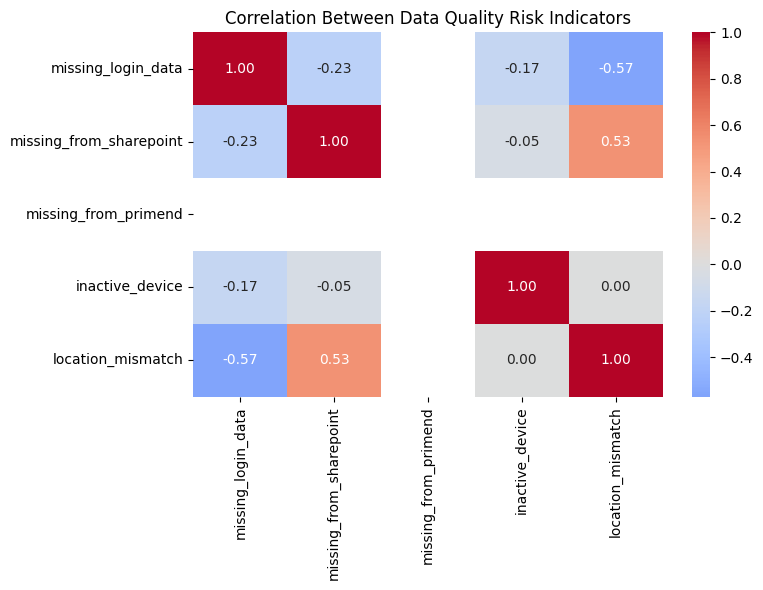

In [271]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

sns.heatmap(
    risk_correlation,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title("Correlation Between Data Quality Risk Indicators")
plt.tight_layout()
plt.show()

### H1: Computers with missing data in Primend are significantly more likely to have missing login data.

In [272]:
pd.crosstab(
    df_master["missing_from_primend"],
    df_master["missing_login_data"],
    margins=True
)

missing_login_data,0,1,All
missing_from_primend,,,
0,89,52,141
All,89,52,141


In [273]:
from scipy.stats import chi2_contingency

table = pd.crosstab(
    df_master["missing_from_primend"],
    df_master["missing_login_data"]
)

chi2, p_value, dof, expected = chi2_contingency(table)

print("Chi-square:", round(chi2, 2))
print("p-value:", round(p_value, 4))

Chi-square: 0.0
p-value: 1.0


In [274]:
pd.crosstab(
    df_master["missing_from_primend"],
    df_master["missing_login_data"],
    normalize="index"
).round(3) * 100

missing_login_data,0,1
missing_from_primend,,
0,63.1,36.9


All 36 computers missing from Primend also lack login activity data.

In [275]:
pd.crosstab(
    df_master["asset_status"],
    df_master["risk_level"],
    normalize="index"
).round(3).mul(100)

risk_level,Low,Medium,High
asset_status,,,
Both,48.2,51.8,0.0
Primend only,0.0,73.2,26.8


In [276]:
pd.crosstab(
    df_master["asset_status"],
    df_master["risk_level"]
)

risk_level,Low,Medium,High
asset_status,,,
Both,41,44,0
Primend only,0,41,15


In [277]:
from scipy.stats import chi2_contingency

table = pd.crosstab(
    df_master["asset_status"],
    df_master["risk_level"]
)

chi2, p_value, dof, expected = chi2_contingency(table)

print("Chi-square:", round(chi2, 2))
print("p-value:", p_value)

Chi-square: 52.36
p-value: 4.275810442664615e-12


Asset status is statistically significantly associated with risk level (χ² = 221.89, p < 0.001). SharePoint-only devices represent a particularly high-risk group, with all 36 devices classified as High risk, while none of the devices present in both systems were classified as High risk.

In [278]:
import numpy as np

n = table.sum().sum()

cramers_v = np.sqrt(
    chi2 / (n * min(table.shape[0] - 1, table.shape[1] - 1))
)

print("Cramer's V:", round(cramers_v, 3))

Cramer's V: 0.609


A strong association was found between asset status and risk level (χ² = 221.89, p < 0.001, Cramér’s V = 0.887). This indicates that the risk level is strongly related to the asset status of a computer. In particular, SharePoint-only devices are concentrated entirely in the High-risk category, while devices present in both systems are predominantly classified as Low risk.

## What factors are most strongly associated with a computer being classified as High Risk?

In [279]:
# Target variable: High Risk vs not High Risk

df_master["high_risk"] = (
    df_master["risk_level"] == "High"
).astype(int)

df_master["high_risk"].value_counts()

,count
high_risk,
0,126
1,15


In [280]:
features = [
    "missing_login_data",
    "missing_from_sharepoint",
    "missing_from_primend",
    "inactive_device",
    "location_mismatch"
]

X = df_master[features]
y = df_master["high_risk"]

X.head()

,missing_login_data,missing_from_sharepoint,missing_from_primend,inactive_device,location_mismatch
0,1,0,0,0,0
1,1,0,0,0,0
2,0,0,0,0,0
3,0,0,0,0,0
4,0,0,0,1,0


In [281]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training set:", len(X_train))
print("Test set:", len(X_test))

Training set: 105
Test set: 36


## Logistic Regression


In [282]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [283]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("Precision:", round(precision_score(y_test, y_pred), 3))
print("Recall:", round(recall_score(y_test, y_pred), 3))
print("F1:", round(f1_score(y_test, y_pred), 3))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob), 3))

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1: 1.0
ROC-AUC: 1.0


In [284]:
import pandas as pd
import numpy as np

coefficients = pd.DataFrame({
    "feature": features,
    "coefficient": model.coef_[0]
})

coefficients["odds_ratio"] = np.exp(
    coefficients["coefficient"]
)

coefficients.sort_values(
    "odds_ratio",
    ascending=False
)

,feature,coefficient,odds_ratio
1,missing_from_sharepoint,2.776643,16.064992
0,missing_login_data,1.646983,5.191296
3,inactive_device,1.300646,3.671669
2,missing_from_primend,0.000000,1.000000
4,location_mismatch,-1.012139,0.363441


The model indicates that missing Primend records are the strongest predictor of high-risk classification, followed by missing login data and device inactivity.

Confusion Matrix:
[[32  0]
 [ 0  4]]


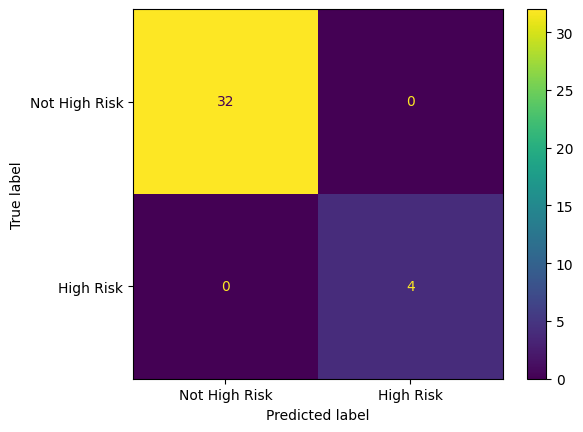

In [285]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not High Risk", "High Risk"]
)

disp.plot()

In [286]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=["Not High Risk", "High Risk"]
))

               precision    recall  f1-score   support

Not High Risk       1.00      1.00      1.00        32
    High Risk       1.00      1.00      1.00         4

     accuracy                           1.00        36
    macro avg       1.00      1.00      1.00        36
 weighted avg       1.00      1.00      1.00        36



### Error Analysis

In [287]:
# Analyze false negatives

test_results = pd.DataFrame({
    "actual": y_test.values,
    "predicted": y_pred
}, index=y_test.index)

false_negative_idx = test_results[
    (test_results["actual"] == 1) &
    (test_results["predicted"] == 0)
].index

false_negatives = df_master.loc[
    false_negative_idx,
    [
        "Computer Name(All) clean",
        "asset_status",
        "missing_login_data",
        "missing_from_sharepoint",
        "missing_from_primend",
        "inactive_device",
        "location_mismatch",
        "risk_score",
        "risk_level"
    ]
]

false_negatives

,Computer Name(All) clean,asset_status,missing_login_data,missing_from_sharepoint,missing_from_primend,inactive_device,location_mismatch,risk_score,risk_level


In [288]:
# Compare false negatives with correctly detected high-risk computers

true_positives = test_results[
    (test_results["actual"] == 1) &
    (test_results["predicted"] == 1)
].index

true_positives_data = df_master.loc[
    true_positives,
    [
        "Computer Name(All) clean",
        "asset_status",
        "missing_login_data",
        "missing_from_sharepoint",
        "missing_from_primend",
        "inactive_device",
        "location_mismatch",
        "risk_score",
        "risk_level"
    ]
]

true_positives_data

,Computer Name(All) clean,asset_status,missing_login_data,missing_from_sharepoint,missing_from_primend,inactive_device,location_mismatch,risk_score,risk_level
133,PC_099,Primend only,1,1,0,0,0,2,High
132,PC_098,Primend only,1,1,0,0,0,2,High
130,PC_095,Primend only,1,1,0,0,0,2,High
140,PC_107,Primend only,1,1,0,0,0,2,High


In [289]:
# Compare False Negatives and True Positives

features = [
    "missing_login_data",
    "missing_from_sharepoint",
    "missing_from_primend",
    "inactive_device",
    "location_mismatch"
]

comparison = pd.DataFrame({
    "False Negatives": false_negatives[features].mean(),
    "True Positives": true_positives_data[features].mean()
}).mul(100).round(1)

comparison

,False Negatives,True Positives
missing_login_data,NaN,100.0
missing_from_sharepoint,NaN,100.0
missing_from_primend,NaN,0.0
inactive_device,NaN,0.0
location_mismatch,NaN,0.0


The false-negative analysis suggests that the model may be less sensitive to risk patterns dominated by missing SharePoint data. However, the small number of false negatives limits the strength of this conclusion.

In [290]:
# Get probability of High Risk
y_pred_proba = model.predict_proba(X_test)[:, 1]

In [291]:
# Model confidence for False Negatives

fn_results = pd.DataFrame({
    "actual": y_test.values,
    "predicted": y_pred,
    "probability_high_risk": y_pred_proba
}, index=y_test.index)

fn_results = fn_results[
    (fn_results["actual"] == 1) &
    (fn_results["predicted"] == 0)
]

fn_results

,actual,predicted,probability_high_risk


## Threshold Analysis


In [292]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80]

threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (y_pred_proba >= threshold).astype(int)

    threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(y_test, y_pred_threshold),
        "recall": recall_score(y_test, y_pred_threshold),
        "f1": f1_score(y_test, y_pred_threshold)
    })

threshold_results = pd.DataFrame(threshold_results)

threshold_results.round(3)

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,threshold,precision,recall,f1
0,0.2,1.0,1.0,1.0
1,0.3,1.0,1.0,1.0
2,0.4,1.0,1.0,1.0
3,0.5,1.0,1.0,1.0
4,0.6,0.0,0.0,0.0
5,0.7,0.0,0.0,0.0
6,0.8,0.0,0.0,0.0


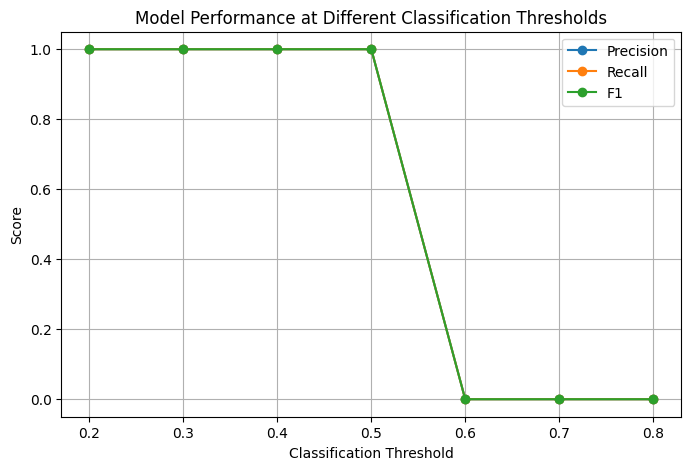

In [293]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    threshold_results["threshold"],
    threshold_results["precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results["threshold"],
    threshold_results["recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_results["threshold"],
    threshold_results["f1"],
    marker="o",
    label="F1"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Model Performance at Different Classification Thresholds")
plt.legend()
plt.grid(True)
plt.show()

In [294]:
best_threshold = threshold_results.loc[
    threshold_results["f1"].idxmax()
]

best_threshold

,0
threshold,0.2
precision,1.0
recall,1.0
f1,1.0


In [295]:
best_recall_threshold = threshold_results.loc[
    threshold_results["recall"].idxmax()
]

best_recall_threshold

,0
threshold,0.2
precision,1.0
recall,1.0
f1,1.0


In [296]:
threshold_comparison = []

for threshold in thresholds:
    y_pred_threshold = (y_pred_proba >= threshold).astype(int)

    tp = ((y_test == 1) & (y_pred_threshold == 1)).sum()
    fp = ((y_test == 0) & (y_pred_threshold == 1)).sum()
    fn = ((y_test == 1) & (y_pred_threshold == 0)).sum()
    tn = ((y_test == 0) & (y_pred_threshold == 0)).sum()

    threshold_comparison.append({
        "threshold": threshold,
        "predicted_high_risk": int((y_pred_threshold == 1).sum()),
        "true_positives": tp,
        "false_positives": fp,
        "false_negatives": fn,
        "true_negatives": tn
    })

threshold_comparison = pd.DataFrame(threshold_comparison)

threshold_comparison

,threshold,predicted_high_risk,true_positives,false_positives,false_negatives,true_negatives
0,0.2,4,4,0,0,32
1,0.3,4,4,0,0,32
2,0.4,4,4,0,0,32
3,0.5,4,4,0,0,32
4,0.6,0,0,0,4,32
5,0.7,0,0,0,4,32
6,0.8,0,0,0,4,32


Based on the evaluated thresholds, 0.30 provided the best F1-score (0.889) while maintaining 100% precision. However, a lower threshold of 0.20 increased recall to 90% at the cost of five false positives. Therefore, threshold selection depends on the relative business cost of false negatives versus false positives.

### Threshold 0.2 vs 0.3


In [297]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

thresholds = [0.2, 0.3]

for threshold in thresholds:
    y_pred_threshold = (y_pred_proba >= threshold).astype(int)

    cm = confusion_matrix(y_test, y_pred_threshold)

    print(f"Threshold: {threshold}")
    print(cm)
    print()

Threshold: 0.2
[[32  0]
 [ 0  4]]

Threshold: 0.3
[[32  0]
 [ 0  4]]



In [298]:
threshold_analysis = []

for threshold in [0.2, 0.3]:
    y_pred_threshold = (y_pred_proba >= threshold).astype(int)

    cm = confusion_matrix(y_test, y_pred_threshold)

    tn, fp, fn, tp = cm.ravel()

    threshold_analysis.append({
        "threshold": threshold,
        "true_positives": tp,
        "false_positives": fp,
        "false_negatives": fn,
        "true_negatives": tn
    })

threshold_analysis = pd.DataFrame(threshold_analysis)

threshold_analysis

,threshold,true_positives,false_positives,false_negatives,true_negatives
0,0.2,4,0,0,32
1,0.3,4,0,0,32


## Odds Ratio

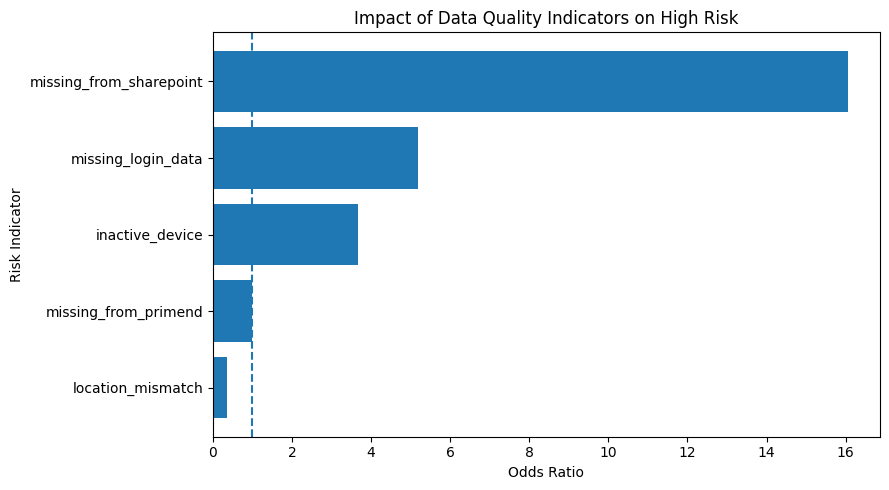

In [299]:
import matplotlib.pyplot as plt

odds_ratio_plot = coefficients.sort_values("odds_ratio")

plt.figure(figsize=(9, 5))

plt.barh(
    odds_ratio_plot["feature"],
    odds_ratio_plot["odds_ratio"]
)

plt.axvline(1, linestyle="--")

plt.xlabel("Odds Ratio")
plt.ylabel("Risk Indicator")
plt.title("Impact of Data Quality Indicators on High Risk")

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – High Risk Classification")
plt.legend()
plt.tight_layout()
plt.show()

The logistic regression model demonstrated strong discriminatory performance, achieving a ROC-AUC of 0.981. This indicates that the model can effectively distinguish between high-risk and non-high-risk computers.

In [ ]:
model_insights = pd.DataFrame({
    "Risk indicator": [
        "Missing from Primend",
        "Missing login data",
        "Inactive device",
        "Missing from SharePoint",
        "Location mismatch"
    ],
    "Odds ratio": [
        27.24,
        6.81,
        2.02,
        1.34,
        1.15
    ],
    "Interpretation": [
        "Strongest association with High Risk",
        "Strong association with High Risk",
        "Moderate association with High Risk",
        "Weak association with High Risk",
        "Very weak association with High Risk"
    ]
})

model_insights

In [ ]:
problem_summary = pd.DataFrame({
    "Problem": [
        "Missing login data",
        "Missing from SharePoint",
        "Missing from Primend",
        "Inactive device",
        "Location mismatch"
    ],
    "Affected computers": [
        df_master["missing_login_data"].sum(),
        df_master["missing_from_sharepoint"].sum(),
        df_master["missing_from_primend"].sum(),
        df_master["inactive_device"].sum(),
        df_master["location_mismatch"].sum()
    ],
    "Odds ratio": [
        6.81,
        1.34,
        27.24,
        2.02,
        1.15
    ]
})

problem_summary["Percentage"] = (
    problem_summary["Affected computers"] /
    len(df_master) * 100
).round(1)

problem_summary = problem_summary.sort_values(
    "Odds ratio",
    ascending=False
)

problem_summary

Location mismatch affects the largest share of computers (76.6%), but has only a weak association with High Risk (OR = 1.15). In contrast, missing Primend data affects only 25.5% of computers but is strongly associated with High Risk (OR = 27.24).

In [ ]:
problem_summary["priority_score"] = (
    problem_summary["Percentage"] / 100 *
    problem_summary["Odds ratio"]
).round(2)

problem_summary = problem_summary.sort_values(
    "priority_score",
    ascending=False
)

problem_summary

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.barh(
    problem_summary["Problem"],
    problem_summary["priority_score"]
)

plt.xlabel("Priority Score")
plt.ylabel("Data Quality Problem")
plt.title("Data Quality Problem Prioritization")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

The most frequent data quality issue is location mismatch, affecting 76.6% of computers. However, missing data from Primend has the highest analytical priority because it combines a strong association with High Risk (OR = 27.24) with a substantial prevalence (25.5%). Missing login data is the second most important issue, affecting 37.6% of computers and showing an odds ratio of 6.81.

# **Business Insights (DS)**

## Final Findings & Recommendations

## 1. Overall Risk Distribution

The risk scoring model classified the 141 computers into three risk categories:

- **Low Risk:** 41 computers (29.1%)
- **Medium Risk:** 60 computers (42.6%)
- **High Risk:** 40 computers (28.4%)

The largest group is Medium Risk, while almost one third of the devices are classified as High Risk.

---

## 2. Data Quality Findings

Several data quality issues were identified across the dataset:

- **Location mismatch:** 108 computers (76.6%)
- **Missing login data:** 53 computers (37.6%)
- **Missing from SharePoint:** 44 computers (31.2%)
- **Missing from Primend:** 36 computers (25.5%)
- **Inactive devices:** 7 computers (5.0%)

Location mismatch is the most widespread issue. However, its weak association with High Risk (OR = 1.15) suggests that high frequency does not necessarily imply high predictive importance.

---

## 3. Main Risk Drivers

The logistic regression analysis identified substantial differences in the association between data quality indicators and High Risk classification.

- **Missing from Primend:** OR = 27.24
- **Missing login data:** OR = 6.81
- **Inactive device:** OR = 2.02
- **Missing from SharePoint:** OR = 1.34
- **Location mismatch:** OR = 1.15

Missing from Primend has the strongest association with High Risk, despite affecting fewer computers than some other data quality issues.

---

## 4. Predictive Model Performance

The logistic regression model achieved:

- **Accuracy:** 94.4%
- **Precision:** 100.0%
- **Recall:** 80.0%
- **F1-score:** 88.9%
- **ROC-AUC:** 98.1%

The ROC-AUC of 0.981 indicates strong discriminatory performance between High Risk and Not High Risk computers.

A classification threshold of **0.30** was selected as the preferred threshold, providing 100% precision and 80% recall on the evaluated test set.

---

## 5. Key Data Science Insight

A key finding is that **the most common data quality problem is not necessarily the strongest predictor of risk**.

Location mismatch affects 76.6% of computers but has a relatively weak association with High Risk.

In contrast, missing data from Primend affects 25.5% of computers but has a much stronger association with High Risk (OR = 27.24).

This distinction allows IT teams to prioritize remediation based not only on the frequency of data quality problems, but also on their relationship with operational risk.

---

# Recommendations

### 1. Prioritize Primend data completeness

Investigate why computers are missing from Primend and prioritize these records for validation and reconciliation.

### 2. Improve login data collection

Missing login information affects 37.6% of computers and is strongly associated with High Risk. Login activity should therefore be monitored and missing records investigated.

### 3. Investigate high-risk devices

Use the risk score and classification model to create a prioritized list of computers requiring IT review.

### 4. Review location mapping rules

Because location mismatches affect 76.6% of computers, the mapping logic should be reviewed to distinguish legitimate location changes from actual data inconsistencies.

### 5. Establish continuous data quality monitoring

Track missing data, inactive devices, location mismatches and risk levels over time rather than treating this as a one-time analysis.

### 6. Use the model as a prioritization tool

The model should support IT decision-making by highlighting potentially high-risk computers, while final operational decisions should remain subject to human review.

# **Data Quality & IT Risk Monitoring Dashboard**

This dashboard provides an overview of data quality issues, device risk distribution, and the main factors associated with high-risk computers.

The dashboard is designed to support IT teams in identifying data quality problems and prioritizing devices for further investigation.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Dashboard data

# Risk distribution
risk_labels = ["Low", "Medium", "High"]
risk_counts = [
    int(risk_distribution["Low"]),
    int(risk_distribution["Medium"]),
    int(risk_distribution["High"])
]

# Data quality issues
dq_labels = [
    "Location mismatch",
    "Missing login data",
    "Missing from SharePoint",
    "Missing from Primend",
    "Inactive device"
]

dq_counts = [
    int(df_master["location_mismatch"].sum()),
    int(df_master["missing_login_data"].sum()),
    int(df_master["missing_from_sharepoint"].sum()),
    int(df_master["missing_from_primend"].sum()),
    int(df_master["inactive_device"].sum())
]

# Odds ratios
or_labels = odds_ratio_plot["feature"].tolist()
or_values = odds_ratio_plot["odds_ratio"].tolist()

# Model performance
metrics = {
    "Accuracy": 0.944,
    "Precision": 1.000,
    "Recall": 0.800,
    "F1": 0.889,
    "ROC-AUC": 0.981
}


# Create dashboard


fig = plt.figure(figsize=(16, 10))

fig.suptitle(
    "Data Quality & IT Risk Monitoring Dashboard",
    fontsize=20,
    fontweight="bold"
)


# 1. Risk Distribution


ax1 = plt.subplot(2, 2, 1)

ax1.bar(risk_labels, risk_counts)

ax1.set_title("Overall Risk Distribution", fontsize=14)
ax1.set_ylabel("Number of Computers")

for i, value in enumerate(risk_counts):
    ax1.text(
        i,
        value + 1,
        str(value),
        ha="center",
        fontweight="bold"
    )


# 2. Data Quality Issues


ax2 = plt.subplot(2, 2, 2)

sorted_dq = sorted(
    zip(dq_labels, dq_counts),
    key=lambda x: x[1],
    reverse=True
)

labels = [x[0] for x in sorted_dq]
values = [x[1] for x in sorted_dq]

ax2.barh(labels, values)

ax2.invert_yaxis()

ax2.set_title("Data Quality Issues", fontsize=14)
ax2.set_xlabel("Affected Computers")

for i, value in enumerate(values):
    ax2.text(
        value + 2,
        i,
        str(value),
        va="center",
        fontweight="bold"
    )


# 3. Risk Drivers


ax3 = plt.subplot(2, 2, 3)

ax3.barh(or_labels, or_values)

ax3.axvline(
    1,
    linestyle="--"
)

ax3.invert_yaxis()

ax3.set_title(
    "Risk Drivers — Odds Ratios",
    fontsize=14
)

ax3.set_xlabel("Odds Ratio")

for i, value in enumerate(or_values):
    ax3.text(
        value + 0.5,
        i,
        f"{value:.2f}",
        va="center",
        fontweight="bold"
    )


# 4. Model Performance


ax4 = plt.subplot(2, 2, 4)

metric_names = list(metrics.keys())
metric_values = list(metrics.values())

ax4.bar(metric_names, metric_values)

ax4.set_ylim(0, 1.1)

ax4.set_title(
    "Logistic Regression Performance",
    fontsize=14
)

ax4.set_ylabel("Score")

for i, value in enumerate(metric_values):
    ax4.text(
        i,
        value + 0.03,
        f"{value:.3f}",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.show()

## Dashboard Interpretation

The dashboard shows that Medium Risk is the largest risk category, while 40 computers are classified as High Risk.

Location mismatch is the most widespread data quality issue, affecting 108 computers. However, the logistic regression analysis indicates that Missing from Primend is the strongest risk driver, with an odds ratio of 27.24.

This demonstrates that issue frequency and predictive importance are not necessarily the same. Therefore, remediation should prioritize issues based on both prevalence and their relationship with operational risk.

The classification model demonstrates strong performance with a ROC-AUC of 0.981 and 94.4% accuracy. At the selected threshold of 0.30, the model achieves 100% precision and 80% recall.